# Assignment-3 COMP-5970 Jacob Murrah
## README
In this assignment, you will capture your own images using a smartphone
and implement key components of classical 3D vision: stereo matching and
structure-from-motion (SfM). This hands-on task will help you appreciate
how camera placement, motion, and calibration influence 3D reconstruction
in practice.

## Dependencies
- **Python 3.x**
- **numpy**
- **matplotlib**
- **opencv-python**
- **ipython**
- **scikit-image**

*Note: If you are running this notebook in Google Colab, all the required packages are pre-installed.*

## Instructions
1. **Run All Cells:** Please click on \"Runtime\" > \"Run all\" to execute the entire notebook sequentially.
2. **Review the Outputs:** The notebook is organized into several sections. Ensure that all cells run without errors.

In [190]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import io
from skimage import color as change
import cv2
from IPython.display import Image
import math

import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

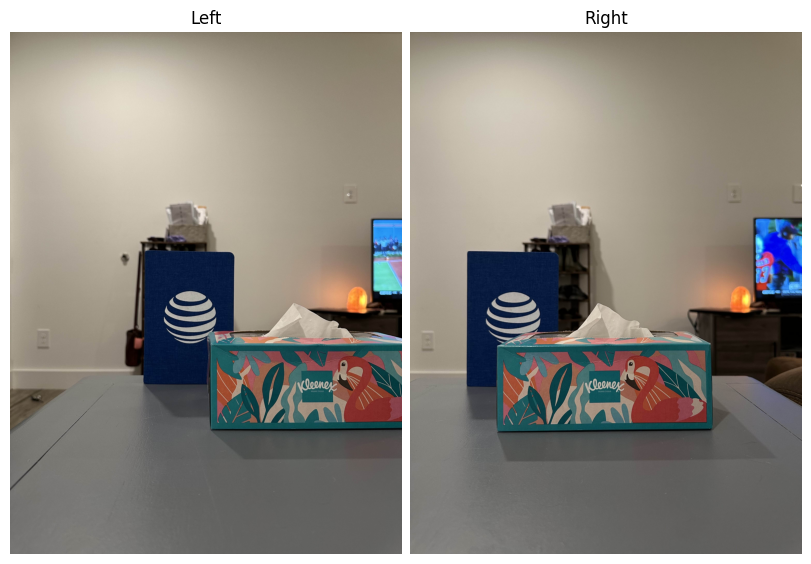

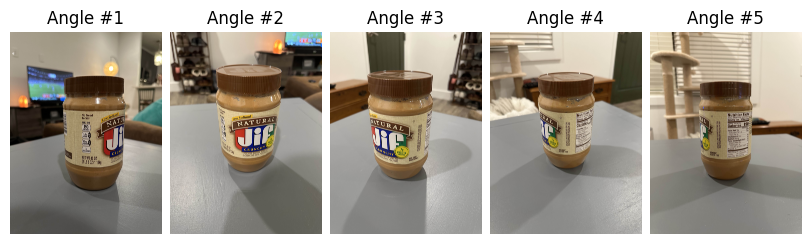

In [191]:
# Loading images

# Stereo Vision Images
left_img = cv2.cvtColor(
    cv2.imread('left.jpg'), cv2.COLOR_BGR2RGB
)
right_img = cv2.cvtColor(
    cv2.imread('right.jpg'), cv2.COLOR_BGR2RGB
)
fig1, axes1 = plt.subplots(1, 2, figsize=(8, 6), constrained_layout=True)
axes1[0].imshow(left_img)
axes1[0].set_title('Left')
axes1[0].axis('off')
axes1[1].imshow(right_img)
axes1[1].set_title('Right')
axes1[1].axis('off')

# Structure from Motion images
angle1_img = cv2.cvtColor(
    cv2.imread('angle1.jpg'), cv2.COLOR_BGR2RGB
)
angle2_img = cv2.cvtColor(
    cv2.imread('angle2.jpg'), cv2.COLOR_BGR2RGB
)
angle3_img = cv2.cvtColor(
    cv2.imread('angle3.jpg'), cv2.COLOR_BGR2RGB
)
angle4_img = cv2.cvtColor(
    cv2.imread('angle4.jpg'), cv2.COLOR_BGR2RGB
)
angle5_img = cv2.cvtColor(
    cv2.imread('angle5.jpg'), cv2.COLOR_BGR2RGB
)
fig2, axes2 = plt.subplots(1, 5, figsize=(8, 6), constrained_layout=True)
axes2[0].imshow(angle1_img)
axes2[0].set_title('Angle #1')
axes2[0].axis('off')
axes2[1].imshow(angle2_img)
axes2[1].set_title('Angle #2')
axes2[1].axis('off')
axes2[2].imshow(angle3_img)
axes2[2].set_title('Angle #3')
axes2[2].axis('off')
axes2[3].imshow(angle4_img)
axes2[3].set_title('Angle #4')
axes2[3].axis('off')
axes2[4].imshow(angle5_img)
axes2[4].set_title('Angle #5')
axes2[4].axis('off')

plt.show()

In [ ]:
from pathlib import Path

DEFAULT_FOV_DEGREES = 60.0
INTRINSICS_CACHE_PATH = Path("assignment3/phone_intrinsics.npz")


def estimate_intrinsics_from_fov(image, fov_degrees=DEFAULT_FOV_DEGREES):
    """Approximate camera intrinsics using an assumed horizontal FOV."""
    height, width = image.shape[:2]
    fov_radians = np.deg2rad(fov_degrees)
    focal_length = max(width, height) / (2.0 * np.tan(fov_radians / 2.0))

    return np.array(
        [
            [focal_length, 0.0, width / 2.0],
            [0.0, focal_length, height / 2.0],
            [0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )


def estimate_phone_intrinsics(
    calibration_images,
    pattern_size=(9, 6),
    square_size_m=0.024,
    use_cache=True,
    cache_path=INTRINSICS_CACHE_PATH,
):
    """Estimate the camera matrix and distortion using chessboard calibration views."""
    calibration_images = list(calibration_images)
    if use_cache and cache_path and cache_path.exists():
        cached = np.load(cache_path)
        return cached["camera_matrix"], cached["dist_coeffs"]

    if not calibration_images:
        raise ValueError("No calibration images supplied. Provide chessboard photos of your phone camera.")

    objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
    objp *= square_size_m

    objpoints, imgpoints = [], []
    for path in calibration_images:
        image = cv2.imread(str(path))
        if image is None:
            continue
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        ret, corners = cv2.findChessboardCorners(gray, pattern_size, None)
        if not ret:
            continue
        criteria = (
            cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
            30,
            1e-4,
        )
        refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        objpoints.append(objp)
        imgpoints.append(refined)

    if not objpoints:
        raise RuntimeError("Failed to detect the calibration pattern in the provided images.")

    ret, camera_matrix, dist_coeffs, *_ = cv2.calibrateCamera(
        objpoints,
        imgpoints,
        gray.shape[::-1],
        None,
        None,
    )
    if not ret:
        raise RuntimeError("Camera calibration did not converge.")

    if use_cache and cache_path:
        np.savez(
            cache_path,
            camera_matrix=camera_matrix,
            dist_coeffs=dist_coeffs,
            pattern_size=pattern_size,
            square_size=square_size_m,
        )

    return camera_matrix, dist_coeffs


def load_intrinsics(
    calibration_images=None,
    fallback_image=None,
    cache_path=INTRINSICS_CACHE_PATH,
    fov_degrees=DEFAULT_FOV_DEGREES,
):
    """Convenience wrapper to grab calibrated intrinsics or fall back to an FOV guess."""
    if calibration_images:
        return estimate_phone_intrinsics(
            calibration_images,
            use_cache=True,
            cache_path=cache_path,
        )

    if cache_path and cache_path.exists():
        cached = np.load(cache_path)
        return cached["camera_matrix"], cached["dist_coeffs"]

    if fallback_image is None:
        raise ValueError("Provide a fallback image when calibration data is unavailable.")

    return estimate_intrinsics_from_fov(fallback_image, fov_degrees), np.zeros(5)


def make_scaled_intrinsics(camera_matrix, fx_scale=1.0, fy_scale=1.0, cx_offset=0.0, cy_offset=0.0):
    """Create a perturbed copy of an intrinsic matrix for sensitivity experiments."""
    scaled = camera_matrix.copy()
    scaled[0, 0] *= fx_scale
    scaled[1, 1] *= fy_scale
    scaled[0, 2] += cx_offset
    scaled[1, 2] += cy_offset
    return scaled


# Task 1) Stereo Vision
Capture two stereo images of a tabletop scene and compute a disparity map.

## Description of Approach
ABC

In [192]:
STEREO_FRAME_SIZE = (756, 567)
BASELINE_INCHES = 5.5
BASELINE_METERS = BASELINE_INCHES * 0.0254


def preprocess_stereo_pair(
    left_rgb,
    right_rgb,
    intrinsics=None,
    dist_coeffs=None,
    frame_size=STEREO_FRAME_SIZE,
):
    left_gray = cv2.cvtColor(left_rgb, cv2.COLOR_BGR2GRAY)
    right_gray = cv2.cvtColor(right_rgb, cv2.COLOR_BGR2GRAY)

    if intrinsics is not None:
        left_gray = cv2.undistort(left_gray, intrinsics, dist_coeffs)
        right_gray = cv2.undistort(right_gray, intrinsics, dist_coeffs)

    left_gray = cv2.resize(left_gray, frame_size)
    right_gray = cv2.resize(right_gray, frame_size)
    return left_gray, right_gray


left_img_original = left_img.copy()
right_img_original = right_img.copy()
calibration_dir = Path('assignment3/calibration')
calibration_images = sorted(calibration_dir.glob('*.jpg'))

try:
    PHONE_K, PHONE_DIST = load_intrinsics(
        calibration_images=calibration_images if calibration_images else None,
        fallback_image=left_img,
    )
except Exception as exc:
    print(f'[WARN] Falling back to FOV-based intrinsics: {exc}')
    PHONE_K, PHONE_DIST = estimate_intrinsics_from_fov(left_img), np.zeros(5)

ACTIVE_INTRINSICS = PHONE_K
ACTIVE_DISTORTION = PHONE_DIST

left_img, right_img = preprocess_stereo_pair(
    left_img,
    right_img,
    intrinsics=ACTIVE_INTRINSICS,
    dist_coeffs=ACTIVE_DISTORTION,
    frame_size=STEREO_FRAME_SIZE,
)


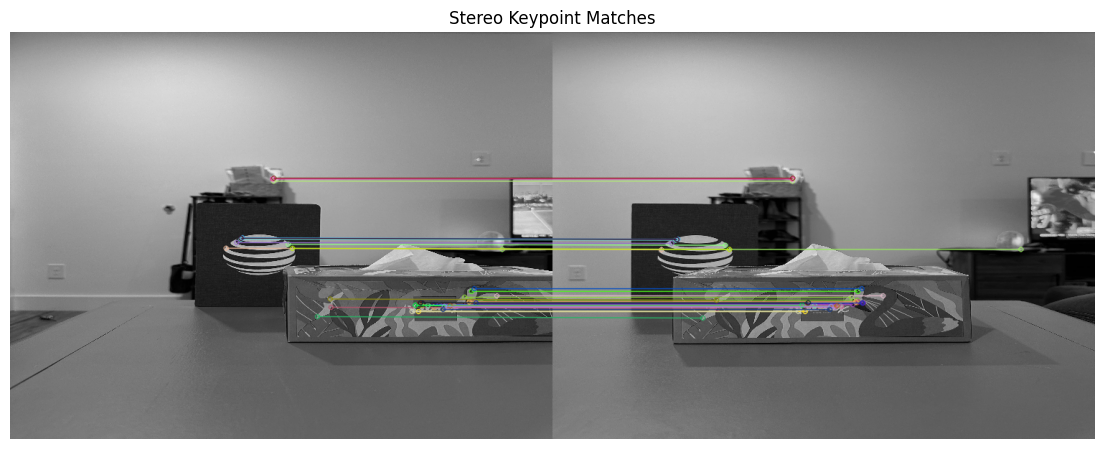

In [193]:
# Part 5a. Detect and match features
def match_stereo_keypoints(l_img, r_img):
    # Initialize ORB detector
    orb = cv2.ORB_create()

    # Detect keypoints and compute descriptors
    kp1, des1 = orb.detectAndCompute(l_img, None)
    kp2, des2 = orb.detectAndCompute(r_img, None)

    # Match descriptors using BruteForce + Hamming
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Draw first 50 matches
    img_matches = cv2.drawMatches(
        left_img, kp1, right_img, kp2, matches[:50], None, flags=2
    )

    # Display
    plt.figure(figsize=(14, 6))
    plt.imshow(img_matches, cmap='gray')
    plt.title('Stereo Keypoint Matches')
    plt.axis('off')
    plt.show()

    return kp1, kp2, matches

kp1, kp2, matches = match_stereo_keypoints(left_img, right_img)


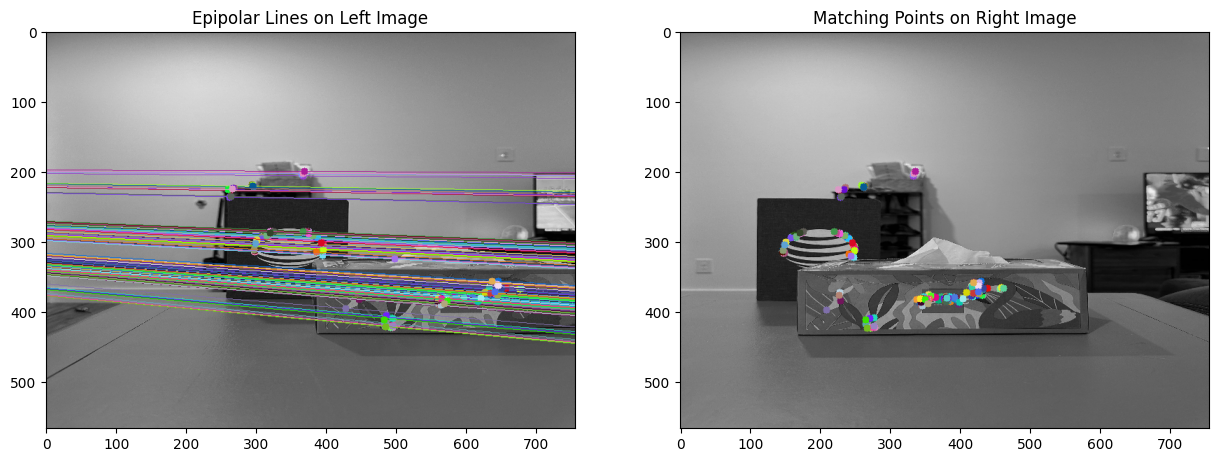

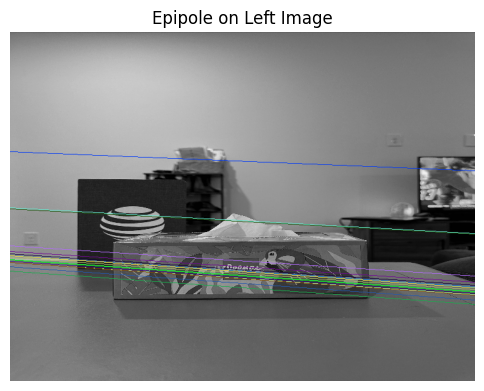

In [194]:
# Part 5b. Estimate the fundamental matrix and draw epipolar lines

def estimate_fundamental_matrix_and_draw_epipolar_lines(
    l_img,
    r_img,
    matches,
    camera_matrix=None,
    dist_coeffs=None,
    max_visualized=30,
):
    def draw_epipolar_lines(img, F, pts, which='left'):
        lines = cv2.computeCorrespondEpilines(
            pts.reshape(-1, 1, 2), 2 if which == 'left' else 1, F
        )
        lines = lines.reshape(-1, 3)

        img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        h, w = img.shape[:2]
        for r in lines:
            a, b, c = r
            if abs(b) < 1e-6:
                x0 = x1 = int(np.clip(-c / a, 0, w - 1))
                y0, y1 = 0, h - 1
            else:
                x0, y0 = 0, int(np.clip(-c / b, 0, h - 1))
                x1, y1 = w - 1, int(
                    np.clip(-(c + a * (w - 1)) / b, 0, h - 1)
                )

            color = tuple(int(v) for v in np.random.randint(0, 255, size=3))
            img_color = cv2.line(img_color, (x0, y0), (x1, y1), color, 1)

        return img_color

    def drawlines(img1, img2, lines, pts1, pts2):
        r, c = img1.shape
        img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
        img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
        for r_line, pt1, pt2 in zip(lines, pts1, pts2):
            color = tuple(np.random.randint(0, 255, 3).tolist())
            a, b, c_line = r_line
            if abs(b) < 1e-6:
                x0 = x1 = int(np.clip(-c_line / a, 0, c - 1))
                y0, y1 = 0, r - 1
            else:
                x0, y0 = 0, int(np.clip(-c_line / b, 0, r - 1))
                x1, y1 = c - 1, int(
                    np.clip(-(c_line + a * (c - 1)) / b, 0, r - 1)
                )
            img1_color = cv2.line(img1_color, (x0, y0), (x1, y1), color, 1)
            img1_color = cv2.circle(
                img1_color, tuple(np.int32(pt1)), 5, color, -1
            )
            img2_color = cv2.circle(
                img2_color, tuple(np.int32(pt2)), 5, color, -1
            )

        return img1_color, img2_color

    if not matches:
        raise ValueError('Need feature matches to estimate epipolar geometry.')

    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    if camera_matrix is not None:
        pts1_norm = cv2.undistortPoints(
            pts1.reshape(-1, 1, 2), camera_matrix, dist_coeffs, P=camera_matrix
        ).reshape(-1, 2)
        pts2_norm = cv2.undistortPoints(
            pts2.reshape(-1, 1, 2), camera_matrix, dist_coeffs, P=camera_matrix
        ).reshape(-1, 2)
        F, mask = cv2.findFundamentalMat(pts1_norm, pts2_norm, cv2.FM_RANSAC)
        pts1_inliers = pts1_norm[mask.ravel() == 1]
        pts2_inliers = pts2_norm[mask.ravel() == 1]
    else:
        F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)
        pts1_inliers = pts1[mask.ravel() == 1]
        pts2_inliers = pts2[mask.ravel() == 1]

    if F is None or F.shape != (3, 3):
        raise RuntimeError('Fundamental matrix estimation failed.')

    lines1 = cv2.computeCorrespondEpilines(pts2_inliers.reshape(-1, 1, 2), 2, F)
    lines1 = lines1.reshape(-1, 3)

    img5, img6 = drawlines(l_img, r_img, lines1, pts1_inliers, pts2_inliers)

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img5, cmap='gray')
    plt.title('Epipolar Lines on Left Image')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(img6, cmap='gray')
    plt.title('Matching Points on Right Image')
    plt.axis('off')
    plt.show()

    sample = min(max_visualized, len(pts1_inliers))
    if sample > 0:
        epilines_img = draw_epipolar_lines(
            r_img,
            F,
            pts2_inliers[:sample],
            which='right',
        )
        plt.figure(figsize=(6, 6))
        plt.imshow(epilines_img, cmap='gray')
        plt.title('Epipolar Geometry (Right Image)')
        plt.axis('off')
        plt.show()

    essential = None
    if camera_matrix is not None:
        essential = camera_matrix.T @ F @ camera_matrix

    return pts1_inliers, pts2_inliers, F, essential


pts1, pts2, F, E = estimate_fundamental_matrix_and_draw_epipolar_lines(
    left_img,
    right_img,
    matches,
    camera_matrix=ACTIVE_INTRINSICS,
    dist_coeffs=ACTIVE_DISTORTION,
)


Epipolar constraint violations:


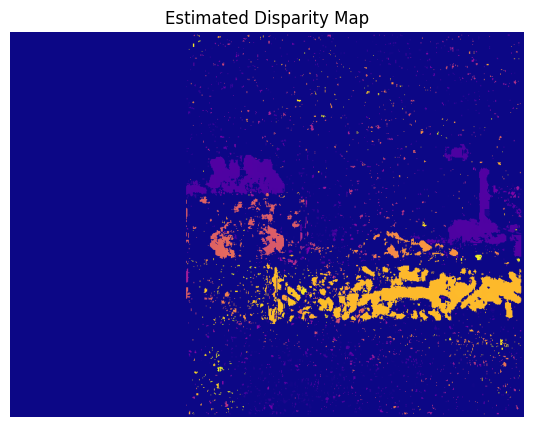

In [195]:
# Part 5c. Compute the disparity map

def disparity_to_depth(disparity, focal_length_px, baseline_m):
    with np.errstate(divide='ignore'):
        depth = (focal_length_px * baseline_m) / disparity
    depth[~np.isfinite(depth)] = np.nan
    return depth


def compute_disparity_and_depth(
    l_img,
    r_img,
    camera_matrix=None,
    baseline_m=BASELINE_METERS,
    num_disparities=256,
    block_size=9,
):
    stereo = cv2.StereoBM_create(numDisparities=num_disparities, blockSize=block_size)
    disparity = stereo.compute(l_img, r_img).astype(np.float32) / 16.0

    disp_vis = cv2.normalize(
        disparity,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX,
    )
    disp_vis = np.uint8(disp_vis)

    plt.figure(figsize=(10, 5))
    plt.imshow(disp_vis, cmap='plasma')
    plt.title('Estimated Disparity Map')
    plt.axis('off')
    plt.show()

    depth = None
    if camera_matrix is not None and baseline_m > 0:
        depth = disparity_to_depth(disparity, camera_matrix[0, 0], baseline_m)

    return disparity, depth


disparity_map, depth_map = compute_disparity_and_depth(
    left_img,
    right_img,
    camera_matrix=ACTIVE_INTRINSICS,
    baseline_m=BASELINE_METERS,
)


Part 5d. Analyze how baseline distance and camera orientation affect disparity quality.

Answer:
In stereo vision we capture a scene from two different angles. Introducing the 2nd angle allows us to capture depth.

The larger the baseline distance, the easier it is to capture the depth in the scene (disparity increases), but it can become more challening to match the two images since the overlapping region reduces. If the baseline is very small, matching the images is easier, but it is more difficult to measure the depth since disparities are so small. Thus a small baseline can lead to very sensitive disparity mappings and a lower depth resolution.

The camera rotations and tilts directly impacts the complexity of the correspondence search between the two images. If the two photos are taken with parallel camera configuration the search is primarily horizontal. If the photos are taken with a toed-in (converging) configuration, the matching is no longer primarily horizontal and the search becomes more complex. Normally this leads to increased disparity error.

Part 6 Write-up (1–2 paragraphs):

a. How did you ensure camera alignment?

Answer: I used a parallel camera configeration and placed my phone on the same table my items were on. There was a horizonal line on the table the I used to ensure my phone wasn't tilted. I also used where the wall and ceiling intersected and lined this up at the top of my camera view to further ensure i wasnt shifting my camera angle.

b. Did the disparity map make sense?

Answer: Somewhat, the closer tissue box was indeed brighter than the notebook. The TV and other things in the background were the darkest. It did not do a good job of completely outlining the objects but it is correctly identifying depth.

c. What happens if the baseline is very small or too large?

Answer: If the baseline is very small there isn't enough disparity between the images and it becomes difficult to measure depth. If the baseline is too large it becomes difficult to find matches between the images since the overlapping regions reduce.

# Task 2) Structure from Motion
Capture a sequence of 3–5 images of a small object or your workspace from
different viewpoints and reconstruct the 3D structure via SfM.

## Description of Approach
ABC

In [ ]:
SFM_FRAME_SIZE = (756, 567)
SFM_RATIO_TEST = 0.75
FLANN_INDEX_KDTREE = 1


def extract_and_match_features(img1, img2, ratio=SFM_RATIO_TEST):
    """Detect SIFT features and run a ratio-tested FLANN match."""
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        return (
            np.empty((0, 2), dtype=np.float32),
            np.empty((0, 2), dtype=np.float32),
        )

    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    matcher = cv2.FlannBasedMatcher(index_params, search_params)

    matches = matcher.knnMatch(des1, des2, k=2)
    pts1, pts2 = [], []
    for best, second in matches:
        if best.distance < ratio * second.distance:
            pts1.append(kp1[best.queryIdx].pt)
            pts2.append(kp2[best.trainIdx].pt)

    return (
        np.array(pts1, dtype=np.float32),
        np.array(pts2, dtype=np.float32),
    )


def draw_epipolar_lines(image, F, points, target="left"):
    """Overlay epipolar lines corresponding to *points* from the other view."""
    if points.size == 0:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    lines = cv2.computeCorrespondEpilines(
        points.reshape(-1, 1, 2), 2 if target == "left" else 1, F
    )
    lines = lines.reshape(-1, 3)

    vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    height, width = image.shape[:2]

    for r in lines:
        a, b, c = r
        if abs(b) < 1e-6:
            x0 = x1 = int(np.clip(-c / a, 0, width - 1))
            y0, y1 = 0, height - 1
        else:
            x0, y0 = 0, int(np.clip(-c / b, 0, height - 1))
            x1, y1 = width - 1, int(
                np.clip(-(c + a * (width - 1)) / b, 0, height - 1)
            )

        color = tuple(int(v) for v in np.random.randint(0, 255, size=3))
        vis = cv2.line(vis, (x0, y0), (x1, y1), color, 1)

    return vis


def visualize_trajectory(trajectory):
    """Plot the camera centers in 3D."""
    camera_centers = np.array([pose[:3, 3] for pose in trajectory])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(camera_centers[:, 0], camera_centers[:, 1], camera_centers[:, 2], "bo-")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Camera Trajectory")
    plt.show()


def visualize_structure(structure):
    """Scatter the accumulated 3D structure."""
    if not structure:
        return

    points = np.vstack(structure)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2, c="g")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Sparse 3D Structure")
    plt.show()


In [ ]:
def run_sfm(
    images,
    intrinsics=None,
    dist_coeffs=None,
    visualize=True,
):
    """Estimate camera trajectory and a sparse point cloud for a small image set."""
    if len(images) < 2:
        raise ValueError("Need at least two images to run structure from motion.")

    if intrinsics is None:
        intrinsics = estimate_intrinsics_from_fov(images[0])
        dist_coeffs = np.zeros(5)
    elif dist_coeffs is None:
        dist_coeffs = np.zeros(5)

    rectified = [
        cv2.undistort(img, intrinsics, dist_coeffs)
        if intrinsics is not None
        else img
        for img in images
    ]

    trajectory = [np.eye(4, dtype=np.float64)]
    structure = []

    for idx in range(len(rectified) - 1):
        img1, img2 = rectified[idx], rectified[idx + 1]

        pts1, pts2 = extract_and_match_features(img1, img2)
        if len(pts1) < 8 or len(pts2) < 8:
            continue

        F, mask_F = cv2.findFundamentalMat(
            pts1,
            pts2,
            method=cv2.FM_RANSAC,
            ransacReprojThreshold=1.0,
            confidence=0.999,
        )
        if F is None or F.shape != (3, 3):
            continue

        inliers1 = pts1[mask_F.ravel() == 1]
        inliers2 = pts2[mask_F.ravel() == 1]
        if len(inliers1) == 0:
            continue

        if visualize:
            sample = min(len(inliers1), 30)
            img1_epi = draw_epipolar_lines(img1, F, inliers2[:sample], target="left")
            img2_epi = draw_epipolar_lines(img2, F, inliers1[:sample], target="right")

            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(img1_epi, cmap="gray")
            plt.title("Epipolar Lines (View 1)")
            plt.axis("off")
            plt.subplot(1, 2, 2)
            plt.imshow(img2_epi, cmap="gray")
            plt.title("Epipolar Lines (View 2)")
            plt.axis("off")
            plt.show()

        if intrinsics is not None:
            E = intrinsics.T @ F @ intrinsics
            recover_args = dict(cameraMatrix=intrinsics)
        else:
            E, _ = cv2.findEssentialMat(
                inliers1,
                inliers2,
                method=cv2.RANSAC,
                prob=0.999,
                threshold=1.0,
            )
            if E is None:
                continue
            recover_args = dict(focal=1.0, pp=(0.0, 0.0))

        _, R, t, mask_pose = cv2.recoverPose(
            E,
            inliers1,
            inliers2,
            **recover_args,
        )

        last_pose = trajectory[-1]
        current_pose = np.eye(4, dtype=np.float64)
        current_pose[:3, :3] = R
        current_pose[:3, 3] = t.ravel()
        trajectory.append(last_pose @ current_pose)

        pose_inliers1 = inliers1[mask_pose.ravel() == 1]
        pose_inliers2 = inliers2[mask_pose.ravel() == 1]
        if len(pose_inliers1) < 8:
            continue

        proj1 = intrinsics @ np.eye(3, 4)
        proj2 = intrinsics @ np.hstack((R, t))

        pts4d = cv2.triangulatePoints(
            proj1,
            proj2,
            pose_inliers1.T,
            pose_inliers2.T,
        )
        pts3d = (pts4d / pts4d[3])[:3].T

        homogeneous_pts = np.hstack(
            (pts3d, np.ones((pts3d.shape[0], 1), dtype=pts3d.dtype))
        )
        pts_cam2 = (np.hstack((R, t)) @ homogeneous_pts.T).T

        valid = (pts3d[:, 2] > 0) & (pts_cam2[:, 2] > 0)
        if valid.any():
            structure.append(pts3d[valid])

    return trajectory, structure


In [ ]:
sfm_images = [
    cv2.resize(cv2.cvtColor(angle1_img, cv2.COLOR_BGR2GRAY), SFM_FRAME_SIZE),
    cv2.resize(cv2.cvtColor(angle2_img, cv2.COLOR_BGR2GRAY), SFM_FRAME_SIZE),
    cv2.resize(cv2.cvtColor(angle3_img, cv2.COLOR_BGR2GRAY), SFM_FRAME_SIZE),
    cv2.resize(cv2.cvtColor(angle4_img, cv2.COLOR_BGR2GRAY), SFM_FRAME_SIZE),
    cv2.resize(cv2.cvtColor(angle5_img, cv2.COLOR_BGR2GRAY), SFM_FRAME_SIZE),
]

trajectory, structure = run_sfm(sfm_images)
visualize_trajectory(trajectory)
visualize_structure(structure)
